In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import os
import dask
import dask.array

import datetime

from collections import Counter

import pystac_client
from pystac.extensions.projection import ProjectionExtension as proj

import planetary_computer
import rasterio
import rasterio.features
from rasterio.features import rasterize

import stackstac
import pyproj

import dask.diagnostics

from shapely.geometry import box
from shapely.ops import transform

from scipy.ndimage import binary_propagation
from scipy.ndimage import label

import sat_tile_stack
from sat_tile_stack import sattile_stack, sat_mask_array, write_netcdf_from_da



In [2]:
## GENERATE A NEW STACK

## CONNECT TO MICROSOFT PLANETARY COMPUTER
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,)
print(f"connected to Microsoft Planetary Computer")

# DECIDE WHETHER TO NORMALIZE THE IMAGERY UPON COMPLIING OR NOT
normalize = False

# READ IN THE LAKE INFORMATION .geojson FILE
gdf = gpd.read_file("/home/jupyter/repos/lake-vision/sandbox/dunmire_cw2019_shuttle.geojson")

# LAKE CENTROID
idx_lake = 825
centroid = (gdf.iloc[idx_lake].centroid_x, gdf.iloc[idx_lake].centroid_y)
# centroid = (-122.33, 37.81) # OAKLAND SEAPORT TERMINALS
# centroid = (-122.45957, 37.80539) # CHRISSY FIELD MARSH
# centroid = (-49.495, 68.725) # NORTH LAKE

print(f"\n working on lake {gdf.iloc[idx_lake].lakenum}")

# SPECIFY TIME RANGE
time_range = '2019-07-01/2019-08-26'

# SPECIFY IMAGERY BANDS
band_names = ["B04",  # red (665 nm)
              "B03",  # green (560 nm)
              "B02",  # blue (490 nm)
              "B08"]  # NIR (842 nm)
              # "B11"]  # SWIR1 (1610 nm)

# CALL FUNCTION TO GENERATE TIMESTACK
gdf_mask = gpd.read_file("/home/jupyter/repos/lake-vision/sandbox/dunmire_cw2019_shuttle.geojson")
gdf_mask = gdf_mask.iloc[[idx_lake]]
timestack = sattile_stack(catalog, centroid, band_names, pix_res=10, tile_size=512, time_range=time_range, normalize=False, mask=gdf_mask, pull_to_mem=True)





connected to Microsoft Planetary Computer

 working on lake 2019cw_826
epsg for bounds_latlon: 3413
pulling stack into memory, shape will be: (57, 5, 512, 512)
[########################################] | 100% Completed | 7.40 ss
shape of stack in memory: (57, 5, 512, 512)


In [5]:
## OPEN PREVIOUSLY-CREATED ARRAY FROM DISK

ds = xr.open_dataset("/home/jupyter/data/2019cw_tstacks/tstack_2019cw_821.nc", engine="netcdf4")
da = ds["reflectance"]
ds_mem = ds.load() 

tiles_reload = ds_mem


In [12]:
# COMPUTE BAND MATH FOR WATER (NDWI, MNDWI, BmG, BmR/BpR)

# WATER INDICES AND MASKS
NDWI = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B08")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B08"))
NDWI = NDWI.fillna(0.0)
mask_NDWI = xr.where(NDWI["reflectance"] >= 0.3, 1.0, 0.0)

# MNDWI = (tiles_reload.sel(band="B02") - tiles_reload.sel(band="B11"))/(tiles_reload.sel(band="B02") + tiles_reload.sel(band="B11"))
# MNDWI = MNDWI.fillna(0.0)

BmG = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B03")) / 10000
BmG = BmG.fillna(0.0)

BmR_BpR = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B04")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B04"))
BmR_BpR = BmR_BpR.fillna(0.0)



KeyError: 'reflectance'

In [3]:
tiles_reload = timestack

# 1) compute & name your NDWI
NDWI = (
    (tiles_reload.sel(band="B02") - tiles_reload.sel(band="B08"))
    / (tiles_reload.sel(band="B02") + tiles_reload.sel(band="B08"))
).fillna(0.0).rename("NDWI")

# 2) build a binary mask where NDWI ≥ 0.3
mask_NDWI = xr.where(NDWI >= 0.3, 1.0, 0.0)

# now mask_NDWI is a DataArray of 0s and 1s, same dims as NDWI
print(mask_NDWI)


<xarray.DataArray 'NDWI' (time: 57, y: 512, x: 512)> Size: 120MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
  

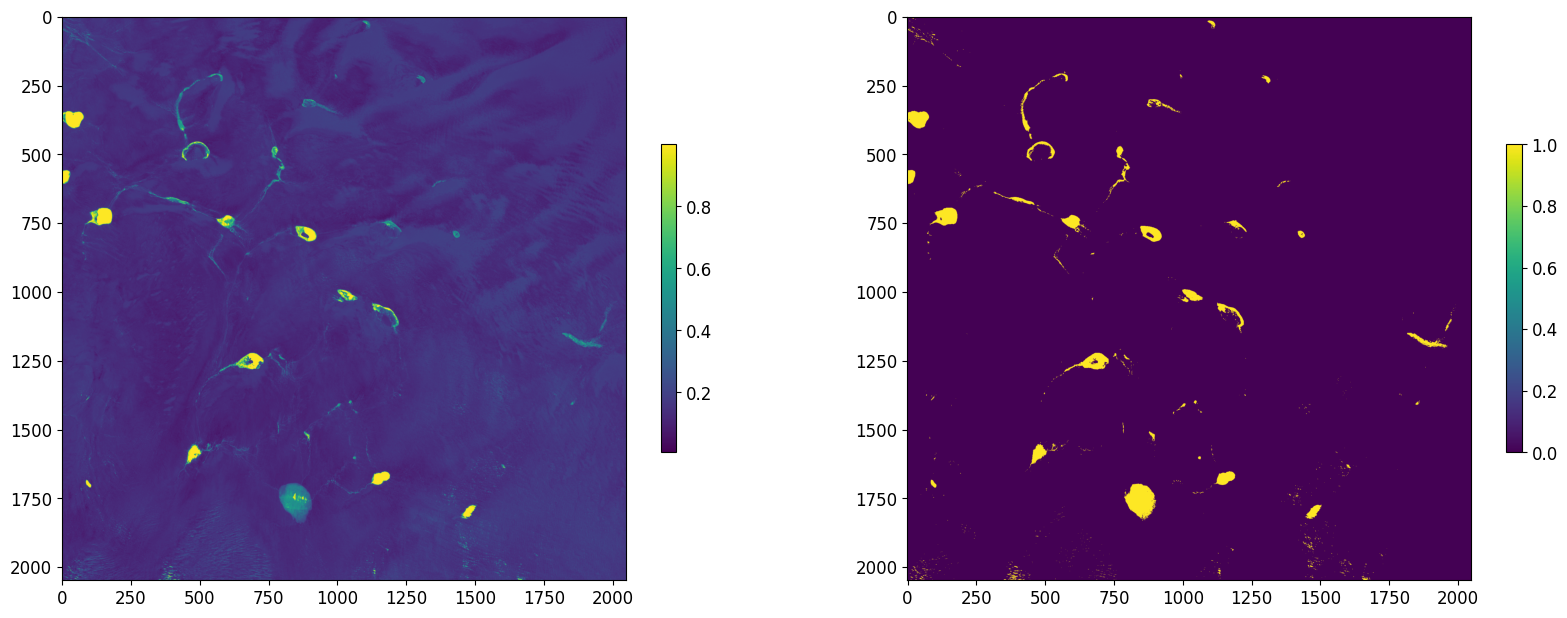

In [101]:
idx_date = 0

plt.figure(figsize=(20,20))

plt.subplot(1,2,1)
plt.imshow(NDWI[idx_date,])
plt.colorbar(shrink=0.2)

plt.subplot(1,2,2)
plt.imshow(mask_NDWI[idx_date,])
plt.colorbar(shrink=0.2)


KeyError: 'reflectance'

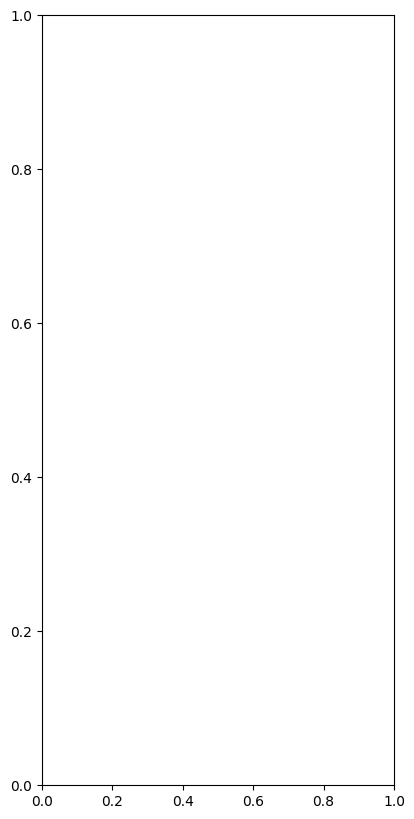

In [14]:
idx_date = 0

plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.imshow(NDWI["reflectance"][idx_date,])
plt.colorbar(shrink=0.2)

plt.subplot(1,2,2)
plt.imshow(mask_NDWI[idx_date,])
plt.colorbar(shrink=0.2)


In [93]:
## CREATE WATER-TRACKER GRID OF SUBTILES THAT AVERAGE THE 

# size of each subtile
BY=BX=8

# compute 
subtile_sums = (
    mask_NDWI
      .coarsen(y=BY, x=BX, boundary="trim")  # chop into subtiles of given size BY=BX
      .sum()                                  # sum within each subtile
)

print(f'subtile grids created with shape: {subtile_sums.shape} ')


subtile grids created with shape: (87, 256, 256) 


In [94]:
## MASKS WATER MOVEMENT PIXELS TO HAVE ID OF LAKE

tiles = subtile_sums
da0   = tiles.isel(time=0)

# Read your vector and pick the subset you care about
gdf = gpd.read_file("/home/jupyter/repos/lake-vision/sandbox/dunmire_cw2019_shuttle.geojson")
gdf = gdf.to_crs(tiles_reload.rio.crs)  # make sure it’s in the same CRS

# Create a numeric code for each lake
#   You can either use a simple 1…N index…
gdf["lake_id"] = np.arange(1, len(gdf) + 1)

# …or map your string “lakenum” to an integer if you want:
# unique_vals = gdf["lakenum"].unique()
# id_map = {val: i+1 for i, val in enumerate(unique_vals)}
# gdf["lake_id"] = gdf["lakenum"].map(id_map)

# Build the shapes iterator: (geometry, lake_id)
shapes = ((geom, lid) for geom, lid in zip(gdf.geometry, gdf.lake_id))

# Rasterize into an integer mask
mask_arr = rasterize(
    shapes,
    out_shape=da0.rio.shape,
    transform=da0.rio.transform(),
    fill=0,        # 0 = “no lake”
    dtype="uint16" # or larger if you have >65535 lakes
)

# Wrap back into an xarray
lake_id_mask = xr.DataArray(
    mask_arr,
    dims=("y", "x"),
    coords={"y": da0.y, "x": da0.x},
    name="lake_id_mask",
)
# (Optional) broadcast if you need the time dims:
full_mask = lake_id_mask\
    .expand_dims(time=tiles.time)\
    .transpose("time","y","x")

# If you want to remember which integer maps to which lakenum:
lake_id_mask.attrs["id_to_lakenum"] = dict(zip(gdf.lake_id, gdf.lakenum))

# print(lake_id_mask)
# print("Legend:", lake_id_mask.attrs["id_to_lakenum"])
print(f"full_mask.shape: {full_mask.shape}")

# GET A LIST OF LAKES THAT ARE PRESENT IN THE CURRENT SCENE

lakes_in_scene = np.unique(full_mask)[1:]
print(f"lake numbers in the current scene: {lakes_in_scene}")



full_mask.shape: (87, 256, 256)
lake numbers in the current scene: [799 803 808 820 821 823 824 826 827 828 829 833 835 838 843 863 865]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1e-04..1.1952].


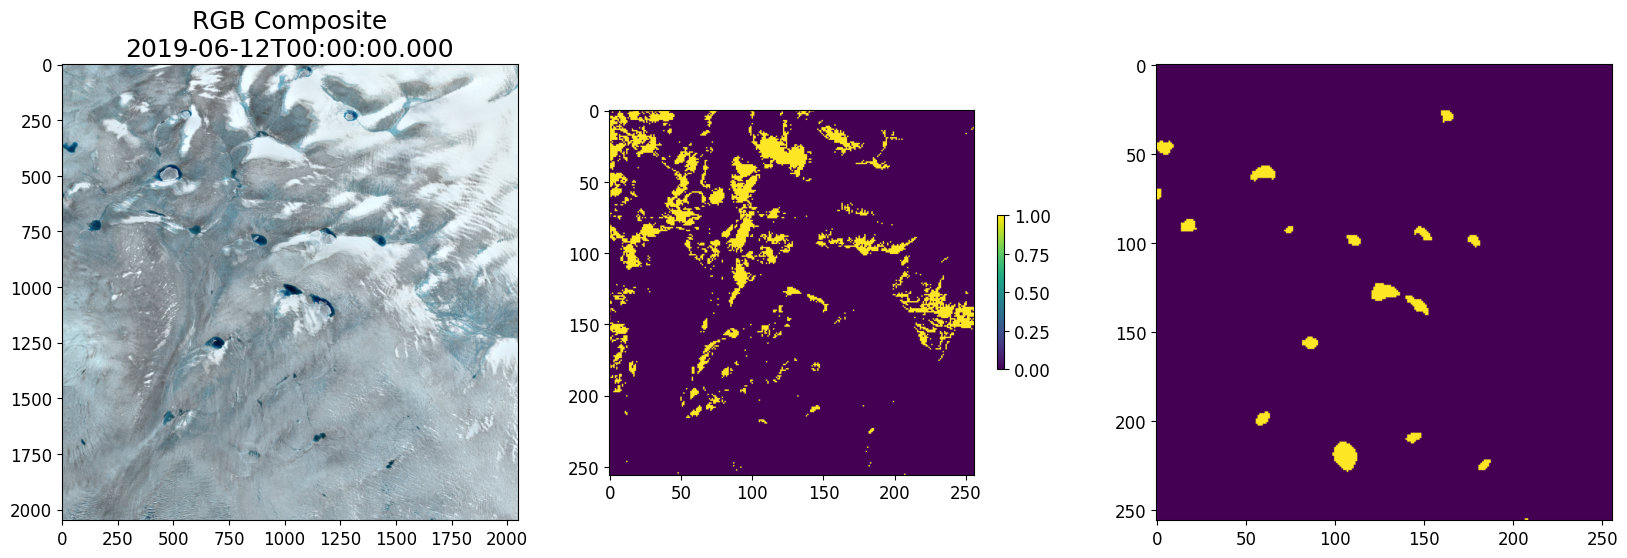

In [100]:
## PLOT RGB, SUBTILE GRID, LAKE IDs

idx_date = 11

plt.figure(figsize=(20,20))
plt.subplot(1,3,1)
# img3 = tiles_reload["reflectance"].isel(time=idx_date, band=[0,1,2]).values/10000   # shape (3, H, W)
img3 = tiles_reload.isel(time=idx_date, band=[0,1,2]).values/10000   # shape (3, H, W)
rgb = np.moveaxis(img3, 0, -1)
plt.imshow(rgb)
plt.title(f"RGB Composite\n{tiles_reload.isel(time=idx_date, band=[0,1,2]).time.values.astype('datetime64[ms]')}")

plt.subplot(1,3,2)
pathway_threshold = 50
B = subtile_sums.values[idx_date,] > pathway_threshold
# B_dilated = binary_dilation(B, structure=kernel, iterations=1)
plt.imshow(B)
# plt.imshow(subtile_sums[idx_date,])
plt.colorbar(shrink=0.1)
# plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(full_mask[idx_date,])
plt.clim(300, 450)



In [45]:
full_mask.shape


(57, 256, 256)

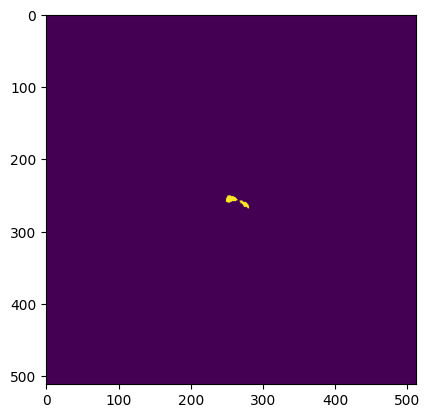

In [23]:
lbl = full_mask[idx_date,]

lake1 = 821
lake2 = 826

twolakes = (lbl == lake1) | (lbl == lake2)

plt.imshow(twolakes)



In [63]:
## DEFINE FUNCTION FOR CHECKING CONNECTIVITY OF TWO LAKES

def lake_conn(idx_lake1, idx_lake2, idx_date, mask_lakeIDs, watergrid, thresh_watergrid):
    
    lbl = mask_lakeIDs[0,]
    
    A = (lbl == lake1) | (lbl == lake2)
    B = watergrid.values[idx_date,]>thresh_watergrid
    
    # label the two islands in A
    islands, n_islands = label(A, structure=np.ones((3,3),bool))
    if n_islands != 2:
        raise ValueError(f"Expected exactly 2 islands in A, got {n_islands}")
        
    # mask for island1
    seed = (islands == 1)

    # allow flooding on both walkway B and island2 itself
    flood_mask = (B==1) | (islands == 2)

    # flood from seed, using 8-connectivity
    reach = binary_propagation(seed, structure=np.ones((3,3),bool), mask=flood_mask)

    # if any pixel of island2 is reached, they’re connected
    connected = np.any( reach & (islands == 2) )
    
    return connected



In [101]:
subtile_sums.time[idx_date]



<xarray.DataArray 'time' ()> Size: 8B
array('2019-06-12T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time            datetime64[ns] 8B 2019-06-12
    constellation   <U10 40B 'Sentinel 2'
    instruments     <U3 12B 'msi'
    gsd             float64 8B 10.0
    epsg            int64 8B 32622
    eo_cloud_cover  float64 8B 1.584
    pct_nans        float64 8B 0.0

In [30]:
## USE FUNCTION ON A GIVEN PAIR OF LAKES ON A GIVEN DATE

# dates: 61, 62, 72, 117

idx_date = 0
connected = lake_conn(821, 826, idx_date, mask_lakeIDs=full_mask, watergrid=subtile_sums, thresh_watergrid=0)

print(
    f"lakes {lake1} and {lake2} connected on {pd.to_datetime(subtile_sums.time[idx_date].values).date()}: {connected}"
)



lakes 821 and 826 connected on 2019-07-01: True


In [11]:
import numpy as np
import itertools
from scipy.ndimage import label

def lake_adjacency(mask_lakeIDs, watergrid, thresh, lakes_in_scene, idx_date):
    """
    Same as before, but convert everything to numpy first so that
    boolean indexing (lbl[mask]) works without xarray errors.
    """
    # 1) grab numpy arrays for this time slice
    #    adjust these two lines to match your actual dims/coords names:
    if hasattr(mask_lakeIDs, "values"):
        lbl = mask_lakeIDs.values[idx_date, ...]
    else:
        lbl = mask_lakeIDs[idx_date, ...]
        
    if hasattr(watergrid, "values"):
        water = watergrid.values[idx_date, ...]
    else:
        water = watergrid[idx_date, ...]

    # 2) build the combined connectivity mask
    water_mask = (water > thresh)
    combined   = water_mask | (lbl > 0)

    # 3) label connected components (8-connectivity)
    comp_id, n_comp = label(combined, structure=np.ones((3,3), bool))

    # 4) prepare output
    lakes = np.array(lakes_in_scene)
    idx_map = {lake: i for i, lake in enumerate(lakes)}
    adj = np.zeros((len(lakes), len(lakes)), dtype=bool)

    # 5) loop over components and connect any lakes that co-occur
    for comp in range(1, n_comp+1):
        mask = (comp_id == comp)
        present = np.unique(lbl[mask])      # now lbl is a NumPy array, so this works
        present = present[present != 0]
        present = np.intersect1d(present, lakes)
        for a, b in itertools.combinations(present, 2):
            i, j = idx_map[a], idx_map[b]
            adj[i, j] = adj[j, i] = True

    return lakes, adj


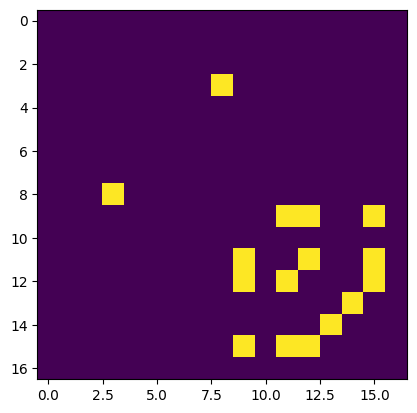

In [88]:

mask_lakeIDs = full_mask
watergrid = subtile_sums
thresh_watergrid = 40
lakes_in_scene = lakes_in_scene

idx_date = 11

lakes, adj = lake_adjacency(mask_lakeIDs, watergrid, thresh_watergrid, lakes_in_scene, idx_date)

plt.imshow(adj)


In [74]:
adj[10,14]



np.False_

In [136]:
# lakes is your 1D array or list of lake-IDs,
# adj   is your (n × n) boolean NumPy matrix
df = pd.DataFrame(adj, index=lakes, columns=lakes)

# In Jupyter, this will render as a nice table:
display(df)

# Or, to print to the console:
# print(df)



,821,826,827,828
821,False,True,False,False
826,True,False,False,False
827,False,False,False,False
828,False,False,False,False


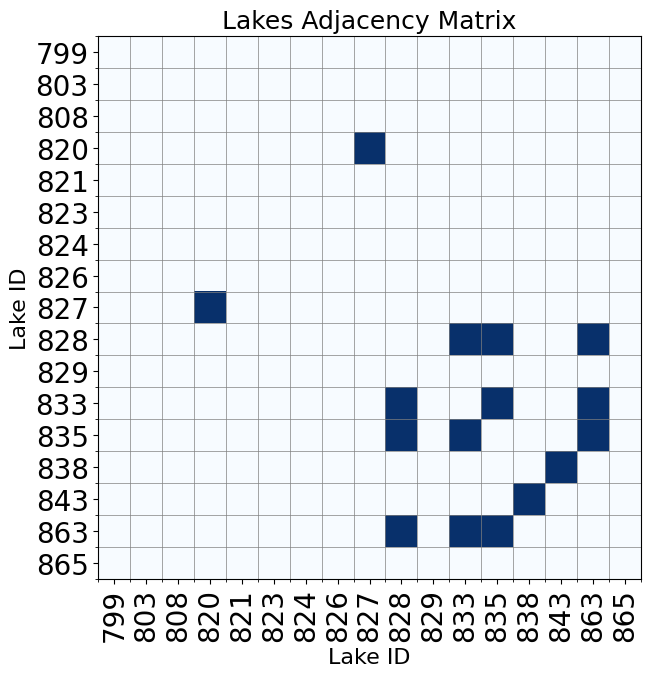

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Recreate your DataFrame
df = pd.DataFrame(adj, index=lakes, columns=lakes)


plt.rcParams.update({
    'font.size': 14,          # base size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x/y labels
    'xtick.labelsize': 12,    # x‐tick labels
    'ytick.labelsize': 12     # y‐tick labels
})

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(df.values, aspect='equal', cmap='Blues')

# Major ticks for labeling
ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df.index)))
ax.set_xticklabels(df.columns, rotation=90, fontsize=20)
ax.set_yticklabels(df.index, fontsize=20)

# Minor ticks for gridlines at cell boundaries
ax.set_xticks(np.arange(-0.5, len(df.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(df.index),   1), minor=True)

# Turn on the grid on those minor ticks
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

# Optional: hide the outer frame so it lines up nicely
ax.set_xlim(-0.5, len(df.columns)-0.5)
ax.set_ylim(len(df.index)-0.5, -0.5)

ax.set_xlabel('Lake ID')
ax.set_ylabel('Lake ID')
ax.set_title('Lakes Adjacency Matrix')

plt.tight_layout()
plt.show()



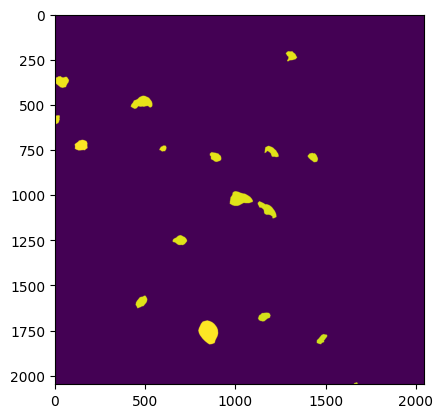

In [64]:
da0 = timestack.isel(time=0).isel(band=0)
shapes = ((geom, lid) for geom, lid in zip(gdf.geometry, gdf.lake_id))

mask_arr_fullres = rasterize(
    shapes,
    out_shape=da0.rio.shape,
    transform=da0.rio.transform(),
    fill=0,        # 0 = “no lake”
    dtype="uint16" # or larger if you have >65535 lakes
)
mask_arr_fullres.shape

plt.imshow(mask_arr_fullres)




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1e-04..1.1464].


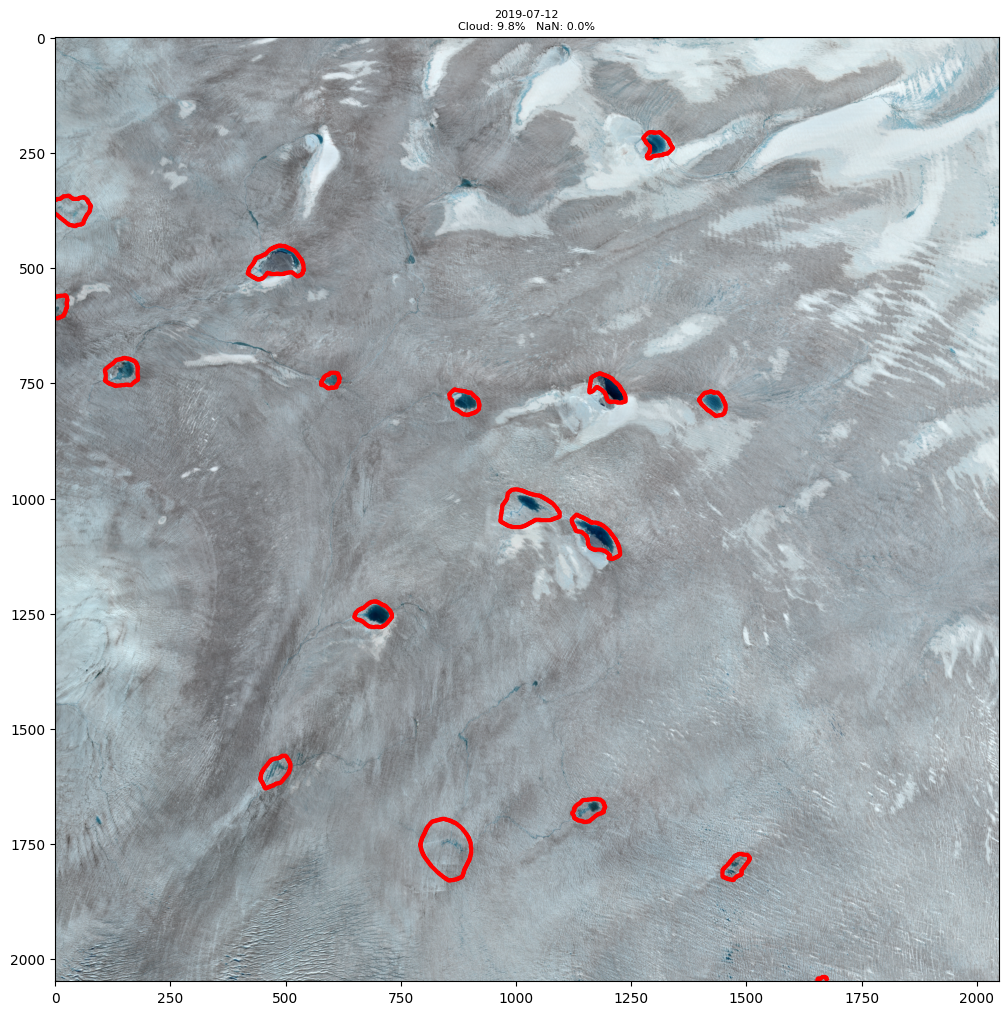

In [73]:
def plot_n_days(timestack, start_date, ndays=10, cols=4):
    """
    Plot consecutive daily RGB composites in subplots, 
    outlining the mask which is assumed to be the last band.

    Parameters
    ----------
    timestack : xarray.DataArray
        DataArray of shape (time, band, y, x), where band=-1 is the mask.
    start_date : str or np.datetime64
        The first date to plot, e.g. "2019-05-20".
    ndays : int
        Number of days to plot.
    cols : int
        Number of columns in the grid.
    """
    start = np.datetime64(start_date)
    rows = int(np.ceil(ndays / cols))
    fig, axes = plt.subplots(rows, cols, 
                             figsize=(cols*10, rows*10), 
                             constrained_layout=True)
    axes_flat = axes.flatten()

    for i in range(ndays):
        date = start + np.timedelta64(i, "D")
        tslice = timestack.sel(time=date)

        # build and stretch RGB from the *first* three bands
        r = tslice.isel(band=0).values
        g = tslice.isel(band=1).values
        b = tslice.isel(band=2).values
        rgb = np.stack([r, g, b], axis=-1)
        # rgb_st = rgb
        # rgb_st = linear_stretch_rgb(rgb, pmin=0, pmax=100)
        rgb_st = rgb/10000

        ax = axes_flat[i]
        ax.imshow(rgb_st)

        # extract the mask (last band) and draw its 0.5 contour
        m2d = tslice.isel(band=-1).values
        m2d = mask_arr_fullres
        ax.contour(m2d, levels=[0.5], colors="red", linewidths=3)

        # pull in the pct_nan and eo_cloud_cover
        pct_nan = float(tslice["pct_nans"].values)
        pct_cloud = float(tslice["eo_cloud_cover"].values)
        
        # add title
        title = (
            f"{str(date)[:10]}\n"
            f"Cloud: {pct_cloud:.1f}%   NaN: {pct_nan:.1f}%"
        )
        ax.set_title(title, fontsize=8)
        # ax.axis("off")

    # remove any empty subplots
    for j in range(ndays, rows*cols):
        fig.delaxes(axes_flat[j])

    plt.show()
    
plot_n_days(timestack, "2019-07-12", ndays=1, cols=5)
